# Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd
from plotnine import *

import requests
import json
import re
from bs4 import BeautifulSoup
from tqdm import tqdm
pd.set_option("display.max_columns", None)

import pickle
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap
import ast  # Helps convert string representations of lists

import gspread
from oauth2client.service_account import ServiceAccountCredentials
from gspread_dataframe import set_with_dataframe

In [ ]:
#!pip install gspread gspread_dataframe oauth2client

# Global Variables

In [2]:
# Set up credentials and connect to Google Sheets
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
creds = ServiceAccountCredentials.from_json_keyfile_name("gsheet-creds.json", scope)
client = gspread.authorize(creds)

# Set up credentials and connect to Google Sheets
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
creds = ServiceAccountCredentials.from_json_keyfile_name("gsheet-creds.json", scope)
client = gspread.authorize(creds)


# Functions

In [3]:
def plot_countplot(
    df,
    col,
    subset_query=None,
    title=None,
    color='#4C72B0',
    horizontal=True,
    figsize=(8, 5),
    show_counts=False
):
    """
    Create a countplot from a column in a pandas DataFrame.

    Parameters:
    -----------
    df : pandas.DataFrame
        Your input DataFrame.
    col : str
        Column to count and plot.
    subset_query : str, optional
        Optional query string to filter the DataFrame (e.g., "type == 'Neither'").
    title : str, optional
        Title for the plot.
    color : str, optional
        Bar color (default: '#4C72B0').
    horizontal : bool, default True
        If True, plot bars horizontally.
    figsize : tuple, optional
        Figure size in inches.
    show_counts : bool, default False
        If True, annotate bars with counts.
    """
    data = df.query(subset_query) if subset_query else df
    order = data[col].value_counts().index

    plt.figure(figsize=figsize)
    ax = sns.countplot(
        data=data,
        y=col if horizontal else None,
        x=None if horizontal else col,
        order=order,
        color=color
    )

    if show_counts:
        for p in ax.patches:
            count = int(p.get_width() if horizontal else p.get_height())
            pos_x = p.get_width() + 0.5 if horizontal else p.get_x() + p.get_width() / 2
            pos_y = p.get_y() + p.get_height() / 2 if horizontal else p.get_height() + 0.5
            if horizontal:
                ax.text(count + 0.5, p.get_y() + p.get_height()/2, str(count), va='center')
            else:
                ax.text(p.get_x() + p.get_width()/2, count + 0.5, str(count), ha='center')

    ax.set_title(title or f"Count of {col}")
    ax.set_xlabel("Count" if horizontal else col)
    ax.set_ylabel(col if horizontal else "Count")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

def View(df, rows=None, cols=None, width=None):
    """Displays the first `rows` of the DataFrame like R's View() by adjusting Pandas settings."""
    
    # Show only the first `rows` of the DataFrame
    with pd.option_context(
        "display.max_rows", rows,  # Limit number of rows shown
        "display.max_columns", cols,  # Show all columns
        "display.max_colwidth", width,  # Show full column width
        "display.expand_frame_repr", False  # Prevent column wrapping
    ):
        display(df.head(rows))  # Show only the first `rows`

# Function to extract mod directory from the URL
def get_dir(url):
    match = re.search(r"file=([^/]+)/[^/]+\.mod", url)  # Extract the directory name before the .mod file
    return match.group(1) if match else None  # Return directory name if found, else None

# Function to extract mod file name without extension
def get_fname(url):
    match = re.search(r"/([^/]+)\.mod$", url)  # Get filename without extension
    return match.group(1) if match else None  # Return only the name (e.g., 'na')

# Function to extract model_id from the URL
def get_model_id(url):
    match = re.search(r"https://modeldb\.science/(\d+)", url)
    return int(match.group(1)) if match else None  # Convert to integer

# Function to extract all TITLE occurrences from .mod content
def get_title(content):
    if pd.isna(content):  
        return None
    matches = re.findall(r"^TITLE\s+([^\n:]+)", content, re.MULTILINE)  # Stop at comments
    return matches if matches else None

# Function to extract all COMMENT sections from .mod content
def get_comment(content):
    if pd.isna(content):  
        return None
    matches = re.findall(r"COMMENT\s+(.*?)(?:\s+ENDCOMMENT|\Z)", content, re.DOTALL)  
    return matches if matches else None

# Function to extract all SUFFIX occurrences from .mod content
def get_suffix(content):
    if pd.isna(content):  
        return None
    matches = re.findall(r"SUFFIX\s+([^\n:\s]+)", content, re.MULTILINE)  # Stop at comments
    return matches if matches else None


def get_use_ion(content):
    """
    Extracts the ion names used in the 'USEION' statements from NEURON mod file content.

    Parameters:
    - content (str): The content of the .mod file.

    Returns:
    - list: A list of ions used in 'USEION' statements, or None if none are found.
    """
    if pd.isna(content):  
        return None
    
    # Find all occurrences of USEION followed by an ion name
    matches = re.findall(r"USEION\s+(\w+)", content, re.MULTILINE)

    return matches if matches else None


# Function to extract all ions listed after READ but stopping before WRITE, USEION, RANGE, GLOBAL, NONSPECIFIC_CURRENT, or VALENCE
def get_read_ion(content):
    if pd.isna(content):  
        return None
    
    matches = re.findall(r"USEION\s+\w+\s+READ\s+([\w,\s]+?)(?=\s+(?:WRITE|USEION|RANGE|GLOBAL|NONSPECIFIC_CURRENT|VALENCE|:|\n|$))", content, re.MULTILINE)

    if not matches:
        return None

    read_ions = [ion.strip() for match in matches for ion in re.split(r"[,\s]+", match) if ion]

    return read_ions if read_ions else None  


# Function to extract all ions listed after WRITE, stopping before VALENCE
def get_write_ion(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"WRITE\s+([^\n:]+?)(?=\s+(?:VALENCE|:|\n|$))", content, re.MULTILINE)

    if not matches:
        return None

    write_ions = [ion.strip() for match in matches for ion in re.split(r"[,\s]+", match) if ion]

    return write_ions if write_ions else None  


def write_current_yn(ions):
    """
    Checks if mod_write_ion contains an ion that starts with 'i' (indicating a current).

    Args:
        write_ions (list): List of ions written in the mod file.

    Returns:
        int: 1 if any ion starts with 'i', otherwise 0.
    """
    if not ions:  # Handle empty lists or None
        return 0

    return int(any(ion.startswith("i") for ion in ions))


# Function to extract all NONSPECIFIC currents
def get_nonspecific_current(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"NONSPECIFIC_CURRENT\s+([^\n:]*)", content)

    if not matches:
        return None

    nonspecific_currents = [curr.strip() for match in matches for curr in re.split(r"[,\s]+", match) if curr]

    return nonspecific_currents if nonspecific_currents else None  

#todo: should we assume we only want active variables or also extract ones that are commented out?
# Function to extract RANGE variables based on mode
def get_range(content, mode="active"):
    if pd.isna(content):
        return None  # Return None if content is missing

    # Extract active RANGE variables (not commented out)
    active_matches = re.findall(r"^\s*RANGE\s+([\w\s,]+)", content, re.MULTILINE)

    # Extract commented-out RANGE variables (lines starting with ": RANGE")
    commented_matches = re.findall(r"^\s*:\s*RANGE\s+([\w\s,]+)", content, re.MULTILINE)

    # Process active RANGE variables
    active_vars = [var.strip() for match in active_matches for var in re.split(r"[,\s]+", match) if var]

    # Process commented-out RANGE variables
    commented_vars = [var.strip() for match in commented_matches for var in re.split(r"[,\s]+", match) if var]

    if mode == "active":
        return active_vars if active_vars else None
    elif mode == "commented":
        return commented_vars if commented_vars else None
    elif mode == "all":
        return {"active": active_vars if active_vars else None, "commented": commented_vars if commented_vars else None}
    else:
        raise ValueError("Invalid mode! Choose from 'all', 'active', or 'commented'.")


# Function to extract only active RANGE variables, stopping at colons and the end of the line
def get_range(content):
    if pd.isna(content):
        return None  # Return None if content is missing

    # Extract all RANGE statements (each line separately), stopping before colons
    matches = re.findall(r"^\s*RANGE\s+([^\n:]*)", content, re.MULTILINE)

    if not matches:
        return None

    # Process active RANGE variables, ensuring they don't capture anything past the colon
    active_vars = [var.strip() for match in matches for var in re.split(r"[,\s]+", match) if var]

    return active_vars if active_vars else None  # Return only active variables
    
# Function to extract parameter names and values as a dictionary
def get_parameter(content):
    if pd.isna(content):  
        return None
    
    matches = re.findall(r"PARAMETER\s*\{([^}]*)\}", content, re.MULTILINE)

    if not matches:
        return None

    param_dict = {}
    
    for match in matches:
        for line in match.split("\n"):
            line = line.strip()
            if line.startswith(":"):  # Ignore commented-out lines
                continue
            param_match = re.match(r"(\w+)\s*=\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", line)
            if param_match:
                param_name, param_value = param_match.groups()
                param_dict[param_name] = float(param_value)  

    return param_dict if param_dict else None  

# Function to extract only active STATE variables, ignoring comments (`:`) and unit values `(mV)`, etc.
def get_state(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"STATE\s*\{([^}]*)\}", content, re.MULTILINE)

    if not matches:
        return None

    state_vars = []
    for match in matches:
        for line in match.split("\n"):
            line = line.strip()
            if line.startswith(":"):  # Ignore fully commented-out lines
                continue
            line = re.split(r"\s*:\s*", line)[0]  # Remove inline comments (anything after `:`)
            clean_line = re.sub(r"\([^)]*\)", "", line).strip()  # Remove unit values
            if clean_line:
                state_vars.append(clean_line)

    return state_vars if state_vars else None  


# Function to extract only active GLOBAL variables, ignoring commented-out (`:`) ones
def get_global(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"^\s*GLOBAL\s+([^\n:]*)", content, re.MULTILINE)

    if not matches:
        return None

    global_vars = [var.strip() for match in matches for var in re.split(r"[,\s]+", match) if var]

    return global_vars if global_vars else None  


def get_net_receive(content):
    """
    Extracts all NET_RECEIVE block arguments from MOD file content.

    Args:
        content (str): The text content of the MOD file.

    Returns:
        list or None: A list of extracted NET_RECEIVE arguments, or None if not found.
    """
    if pd.isna(content):  # Handle missing content
        return None

    # Find all occurrences of NET_RECEIVE and extract arguments
    matches = re.findall(r"^\s*NET_RECEIVE\s*\(\s*([\w, ]+)\s*\)", content, re.MULTILINE)

    if not matches:
        return None

    net_receive_vars = [var.strip() for match in matches for var in re.split(r"[,\s]+", match) if var]

    return net_receive_vars if net_receive_vars else None

#todo: modify pipeline so that if get_include points to a file that file will be included in the content too
def get_include(content):
    """
    Extracts the filename in the INCLUDE statement from MOD file content, ignoring comments.

    Args:
        content (str): The text content of the MOD file.

    Returns:
        list or None: A list of extracted INCLUDE filenames, or None if not found.
    """
    if pd.isna(content):  # Handle missing content
        return None

    # Find all occurrences of INCLUDE, ensuring commented-out ones (with ':') are ignored
    matches = re.findall(r"^\s*INCLUDE\s+\"([^\"]+)\"", content, re.MULTILINE)

    return matches if matches else None


def get_point_process(content):
    """
    Extracts the POINT_PROCESS name from MOD file content.

    Args:
        content (str): The text content of the MOD file.

    Returns:
        str or None: The extracted POINT_PROCESS name, or None if not found.
    """
    if pd.isna(content):  # Handle missing content
        return None

    # Extract the POINT_PROCESS name, ignoring comments
    match = re.search(r"^\s*POINT_PROCESS\s+([^\n:]+)", content, re.MULTILINE)

    return match.group(1).strip() if match else None


    
# Function to extract webpage heading
def get_heading(url):
    try:
        response = requests.get(url, timeout=10)  # Fetch the webpage
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "html.parser")
        
        # Try extracting heading from the most relevant tag
        heading = soup.find("h1")  # Look for <h1> (main title)
        return heading.text.strip() if heading else None  # Return text or None
    except requests.exceptions.RequestException:
        return None  # Return None if the request fail

# Function to extract citation (text inside parentheses)
def get_citation(heading):
    if pd.isna(heading):
        return None
    match = re.search(r"\(([^)]+)\)", heading)  # Find text inside parentheses
    return match.group(1) if match else None  # Extract citation


# Function to extract first author(s) (removes "et al." and "al" correctly)
def get_author(citation):
    if pd.isna(citation):
        return None

    # Extract first author(s) before "et al" or variants
    match = re.search(r"^([\w\s&\-,]+?)(?:\s+et\s+al\.?|et)?(?:,|\s|$)", citation)  
    first_author = match.group(1).strip() if match else None  

    # Remove any trailing "al" left behind
    if first_author:
        first_author = re.sub(r"\b(al)\b", "", first_author, flags=re.IGNORECASE).strip()

    return first_author

# Function to extract the first year from citation (including shortened years like '20)
def get_year(citation):
    if pd.isna(citation):
        return None
    match = re.search(r"\b(19|20)?\d{2}\b|'\d{2}", citation)  # Find 4-digit or short year ('20)
    if match:
        return match.group(0).replace("'", "")  # Remove apostrophe but keep year as '20' if short
    return None  # Return None if no year found






def has_electrode_or_clamp(mod_name, content):
    """
    Checks whether 'clamp' is present in the mod file name OR 
    'ELECTRODE_CURRENT' is present in the NEURON mod file content.

    Parameters:
    - mod_name (str): The name of the .mod file.
    - content (str): The content of the .mod file.

    Returns:
    - int: 1 if either 'clamp' is in the mod name OR 'ELECTRODE_CURRENT' is in the content, 0 otherwise.
    """
    if pd.isna(mod_name) and pd.isna(content):
        return None  # Return None if both are missing

    has_clamp = bool(re.search(r"clamp", str(mod_name), re.IGNORECASE)) if pd.notna(mod_name) else False
    has_electrode = bool(re.search(r"\bELECTRODE_CURRENT\b", str(content))) if pd.notna(content) else False

    return 1 if has_clamp or has_electrode else 0

def map_ion(value):
    value = value.lower()  # Normalize to lowercase

    # Define regex-based categorization rules
    patterns = [
        (r'ca.*i$', 'ca_i'),
        (r'ca.*o$', 'ca_o'),
        (r'cl.*i$', 'cl_i'),
        (r'cl.*o$', 'cl_o'),
        (r'k.*i$', 'k_i'),
        (r'k.*o$', 'k_o'),
        (r'na.*i$', 'na_i'),
        (r'na.*o$', 'na_o'),
        (r'hco3.*i$', 'other_i'),
        (r'hco3.*o$', 'other_o'),
        (r'mgi$', 'mg_i'),  
        (r'mgo$', 'mg_o'),  
        (r'^img$', 'i_mg'),  
        (r'^emg$', 'e_mg'),
        (r'^e.*ca', 'e_ca'),
        (r'^e.*k', 'e_k'),
        (r'^e.*na', 'e_na'),
        (r'^e.*mg', 'e_mg'),
        (r'^e.*', 'e_other'),
        (r'^i.*ca', 'i_cal'),
        (r'^i.*k', 'i_k'),
        (r'^i.*cl', 'i_cl'),
        (r'^i.*na$', 'i_na'),  # FIX: Ensure "ina" is classified as "i_na"
        (r'^i.*mg', 'i_mg'),
        (r'^i.*', 'i_other'),
        (r'.*i$', 'other_i'),  # General rule: Anything ending in "i" is "other_i"
        (r'.*o$', 'other_o')   # General rule: Anything ending in "o" is "other_o"
    ]
    # Apply the regex patterns
    for pattern, category in patterns:
        if re.search(pattern, value):
            return category

    return "unknown"  # Default category if no match is found

def count_states(df, column_name="state"):
    """Counts the number of states in each row of the specified column."""
    df["count_states"] = df[column_name].apply(lambda x: len(x) if isinstance(x, list) else 0)
    return df



def get_tau(param_dict):
    if not isinstance(param_dict, dict):
        return None, None  # Return separate None values for direct unpacking

    # Extract values where the key contains 'tau'
    tau_values = [v for k, v in param_dict.items() if 'tau' in k.lower()]
    
    # If no tau values found, return (None, None)
    if not tau_values:
        return None, None
    
    # Compute min and max
    return min(tau_values), max(tau_values)


def get_e(param_dict):
    if not isinstance(param_dict, dict):
        return [None, None]  # Handle cases where the value is not a dictionary

    #todo: modify the v pattern so it takes like 2 characters max
    # Regex pattern to match variations of reversal potential names
    pattern = re.compile(r"^(e|rev|v|shift).*", re.IGNORECASE)

    # Extract values where the key matches the pattern
    e_values = [v for k, v in param_dict.items() if pattern.match(k)]

    # If no values found, return [None, None]
    if not e_values:
        return [None, None]

    # Compute min and max reversal potential
    return min(e_values), max(e_values)



def has_mg(content):
    """
    Checks if 'mg' appears anywhere in the given content.

    Args:
        content (str): The text content to search.

    Returns:
        int: 1 if 'mg' is found, 0 otherwise.
    """
    if pd.isna(content):  # Handle missing content
        return 0

    return int(bool(re.search(r"mg", content, re.IGNORECASE)))  # Convert Boolean to int


def has_ih(content):

    if pd.isna(content):  # Handle missing content
        return 0

    return int(bool(re.search(r"ih", content, re.IGNORECASE)))  # Convert Boolean to int

def plot_countplot(
    df,
    col,
    subset_query=None,
    title=None,
    color='#4C72B0',
    horizontal=True,
    figsize=(8, 5),
    show_counts=False
):
    """
    Create a Seaborn countplot with options for filtering, orientation, and annotations.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input data.
    col : str
        Column to count and plot.
    subset_query : str, optional
        Pandas query string to filter data before plotting (e.g., "type == 'Neither'").
    title : str, optional
        Title of the plot.
    color : str, optional
        Color of the bars.
    horizontal : bool, default True
        If True, plot horizontal bars; else vertical.
    figsize : tuple, default (8, 5)
        Figure size.
    show_counts : bool, default False
        If True, annotate bars with counts.
    """
    data = df.query(subset_query) if subset_query else df
    order = data[col].value_counts().index

    plt.figure(figsize=figsize)
    ax = sns.countplot(
        data=data,
        y=col if horizontal else None,
        x=None if horizontal else col,
        order=order,
        color=color
    )

    if show_counts:
        for p in ax.patches:
            count = int(p.get_width() if horizontal else p.get_height())
            if horizontal:
                ax.text(
                    p.get_width() + 0.5,
                    p.get_y() + p.get_height() / 2,
                    str(count),
                    va='center'
                )
            else:
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    p.get_height() + 0.5,
                    str(count),
                    ha='center'
                )

    ax.set_title(title or f'Count of {col}')
    ax.set_xlabel('Count' if horizontal else col)
    ax.set_ylabel(col if horizontal else 'Count')
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()

# Highlight count < 10
def highlight_rare_rows(row):
    color = 'background-color: lightcoral' if row['count'] < 10 else ''
    return [color] * len(row)


def get_count_df(df, group_cols, sort_col=None):
    if sort_col is None:
        sort_col = group_cols[0]
    
    return (
        df
        .groupby(group_cols)
        .size()
        .reset_index(name='count')
        .assign(
            overall_pct = lambda d: (d['count'] / d['count'].sum() * 100).round(2),
            subtype_pct = lambda d: (
                d.groupby(group_cols[0])['count']
                .transform(lambda x: (x / x.sum()) * 100)
                .round(2)
            )
        )
        .sort_values([sort_col, 'count'], ascending=[True, False])
    )

def plot_partial_credit_heatmap(y_true, y_pred, similarity_matrix):
    """
    Plots a heatmap of average similarity scores between true and predicted labels.
    
    Parameters:
    - y_true: list or array of true labels (strings)
    - y_pred: list or array of predicted labels (strings)
    - similarity_matrix: pandas DataFrame with labels as index and columns, containing similarity scores
    """
    # Get all unique labels
    all_labels = sorted(set(y_true) | set(y_pred))
    
    # Build confusion-style count matrix
    confusion_counts = pd.DataFrame(0, index=all_labels, columns=all_labels)
    for true, pred in zip(y_true, y_pred):
        confusion_counts.loc[true, pred] += 1

    # Compute similarity-weighted scores
    weighted_scores = confusion_counts * similarity_matrix

    # Normalize to average similarity per true label
    normalized_similarity = weighted_scores.div(confusion_counts.sum(axis=1).replace(0, np.nan), axis=0)

    # Plot heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(normalized_similarity, annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title("Average Partial Credit Score: True vs Predicted")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


# Key Variables

In [4]:
#These are subtypes with counts < 10
RARE_SUBTYPES = ['I Na (Rare)',
 'I Ca (Rare)',
 'I K (Leak)',
 'I Other (Rare)',
 'I Na (Leak)',
 'R Other (Rare)',
 'I Cl ']


COMMON_SUBTYPES_ROBERT = ['I R',
 'I Ca,p',
 'I p,q',
 'I L high threshold',
 'I T low threshold',
 'I h',
 'I A',
 'I A',
 'I_AHP',
 'IK Bkca',
 'IK Skca',
 'I K,Ca',
 'I_KD',
 'I M',
 'I KLT',
 'I K',
 'I Potassium',
 'I_KHT',
 'Kir',
 'I K, I K,s',
 'I Ks',
 'I Sodium',
 'I Na,p',
 'I Na,t',
 'I CAN',
 'I N',
 'Ca pump',
 'Na/K pump',
 'Na/Ca exchanger',
 'GabaA',
 'Gaba',
 'GabaB',
 'AMPA',
 'NMDA']

# Import Data

## Google Sheet (Labels)

In [5]:
# Open the sheet by name
sheet = client.open("label_df").sheet1

# Read sheet data into DataFrame
data = sheet.get_all_records()
label_df = pd.DataFrame(data).query("new_subtype_label not in @RARE_SUBTYPES")

label_df_long = (
    label_df
    .assign(
        robert_subtype_label=label_df['robert_subtype_label']
        .str.split(' \|\| ')
    )
    .explode('robert_subtype_label')
    .assign(
        robert_subtype_label=lambda df: df['robert_subtype_label']
        .str.strip()
        .replace("", pd.NA)
    )
)

## Annotated Excel Sheet

In [6]:
fp = "/gpfs/gibbs/project/mcdougal/imc33/mod-extract/data/model_db_annotations.xlsx"
raw_ant_df_wide = pd.read_excel(fp).query("annotated == 'y'")

missing_subtype1_df = raw_ant_df_wide[raw_ant_df_wide["subtype_1"].isna()]

raw_ant_df_long = (raw_ant_df_wide
    .melt(
        id_vars=[col for col in raw_ant_df_wide.columns if col not in ['subtype_1', 'subtype_2', 'subtype_3', 'subtype_4', 'subtype_5']],
        value_vars=['subtype_1', 'subtype_2', 'subtype_3', 'subtype_4', 'subtype_5'],
        var_name="subtype_num",
        value_name="original_subtype_label"
    ))

ant_df_long = (raw_ant_df_long
    .dropna(subset=["original_subtype_label"])
    #Exclusion Criteria here 
    .query("subtype_confidence != '1 - Not confident at all'")
    .query("type != 'Exclude'")
    .drop(columns=['raw_sha','count','url','mod_file','ask_robert','annotated','Robert reviewed','subtype_num'])
    .merge(label_df, on="original_subtype_label", how="left")
    .sort_values('row_id')
    .query("type != 'I Multi'")
    .query("type != 'R Multi'")
    .query("new_subtype_label not in @RARE_SUBTYPES")
   # .assign(
   #     type = lambda df: np.where(
   #         df["type"] == "I Multi",
   #         df["original_type_label"],
   #         df["type"]
   #     )
    ).drop(columns=["robert_subtype_label"])


/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed


## GPT-4
- These are the subtypes present in our 1k annotation set that are missing from GPT
- Not shown, the GPT dataset included the following: "D1', 'D2', 'Dopaminergic Receptor', 'M1', 'M2', 'M3', 'M4'" which are missing form our 1k dataset

In [7]:
raw_gpt_df = pd.read_csv("../data/mod_files_gpt.csv", usecols=["hash","currents_at_least_3"]).rename(columns={"currents_at_least_3":"gpt_pred"})
raw_gpt_df.head()

,hash,gpt_pred
0,cf53b079807fc6711d9563031aae227dd1a73cf5add973...,"[""IK Skca""]"
1,04c32cd101754ad7f2eaf278919c6ce85b8a7d67149fca...,"[""I Potassium"", ""I Calcium"", ""NMDA"", ""I Sodium""]"
2,2d3c5c121271cfad6d2e35db7d2c418de64f97e57c20a0...,"[""I T low threshold""]"
3,e2f71ea16f8378b3cf0670f9bd5e457634824ab9ee8a7c...,"[""I K""]"
4,04860f65d331d381e779e488566f95ab0e1fa4960b50a7...,[]


In [ ]:
#'D1', 'D2', 'Dopaminergic Receptor', 'M1', 'M2', 'M3', 'M4'
#label_df_long[label_df_long.robert_subtype_label.isna()]

In [8]:
import ast
import pandas as pd

gpt_df2 = (
    raw_gpt_df
    .assign(gpt_pred=lambda df: df['gpt_pred'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x))
    .explode('gpt_pred')
    .assign(gpt_pred=lambda df: df['gpt_pred'].str.strip().replace("", pd.NA))
)

In [9]:
gpt_df3 = (gpt_df2
         .query("gpt_pred in @COMMON_SUBTYPES_ROBERT")
         .query("gpt_pred not in @RARE_SUBTYPES")
         .merge(label_df_long, how="left", left_on=["gpt_pred"], right_on=["robert_subtype_label"])
        .drop(columns=["gpt_pred","original_type_label","robert_subtype_label","original_subtype_label"])
        .rename(columns={"new_subtype_label":"gpt_pred"})
          )

# Create New Subtype Labels
- If count < 10, then collapse into another category; if no category fits, then collapse into Rare
- This is the google sheet: https://docs.google.com/spreadsheets/d/1gZ9pdoGwL_jVwC8APBZ_zb0jzLwl2hg3hIdfmLLEmRY/edit?gid=235253285#gid=235253285

In [10]:
count_df  = get_count_df(ant_df_long, ['type', 'original_subtype_label'])
count_df2 = get_count_df(ant_df_long, ['type', 'new_subtype_label'])
count_df.sort_values(['type','original_subtype_label'], ascending=[True, False]).reset_index().style.apply(highlight_rare_rows, axis=1)

,index,type,original_subtype_label,count,overall_pct,subtype_pct
0,5,I Ca,I Ca (T-type LT),20,2.630000,26.670000
1,4,I Ca,I Ca (R-Type),7,0.920000,9.330000
2,3,I Ca,I Ca (Q-Type),2,0.260000,2.670000
3,2,I Ca,I Ca (P/Q-Type),3,0.390000,4.000000
4,1,I Ca,I Ca (L-Type HT),38,4.990000,50.670000
5,0,I Ca,I Ca (General),5,0.660000,6.670000
6,6,I Cl,I Cl (Leak),1,0.130000,100.000000
7,7,I H,I H (Hyperpolarization-Activated),38,4.990000,100.000000
8,25,I K,I Kx (Photoreceptor),2,0.260000,0.850000
9,24,I K,I K (Slow),2,0.260000,0.850000


In [11]:
count_df2.style.apply(highlight_rare_rows, axis=1)

,type,new_subtype_label,count,overall_pct,subtype_pct
1,I Ca,I Ca (L-Type HT),38,5.160000,54.290000
2,I Ca,I Ca (T-type LT),20,2.710000,28.570000
0,I Ca,I Ca (HVA),12,1.630000,17.140000
3,I H,I H,38,5.160000,100.000000
4,I K,I K (A-type),71,9.630000,30.740000
6,I K,I K (Delayed Rectifier),54,7.330000,23.380000
5,I K,I K (Ca-activated),53,7.190000,22.940000
7,I K,I K (M-type),28,3.800000,12.120000
8,I K,I K (Rare),25,3.390000,10.820000
11,I Na,I Na (Transient),56,7.600000,65.120000


# Create Plots

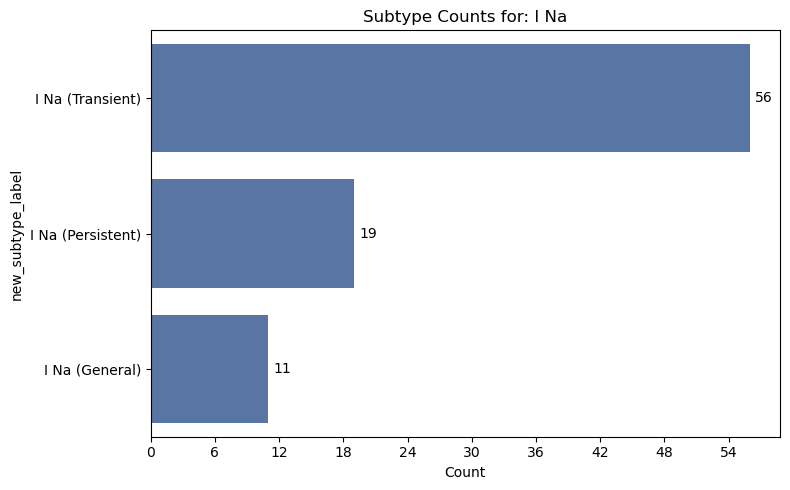

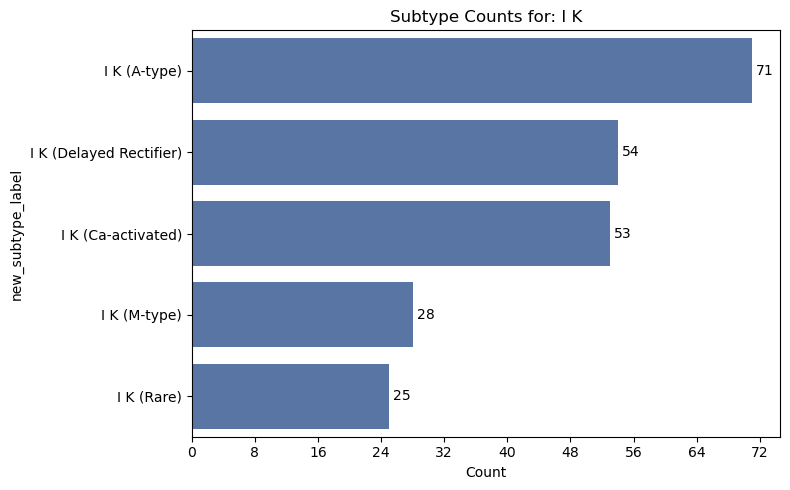

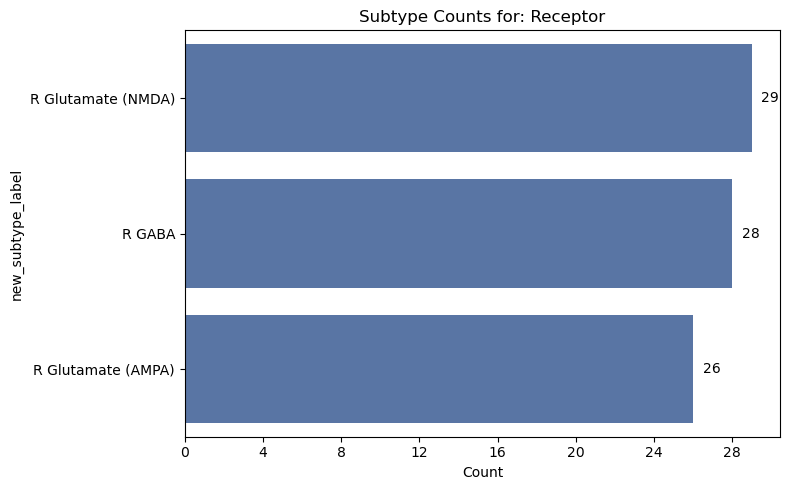

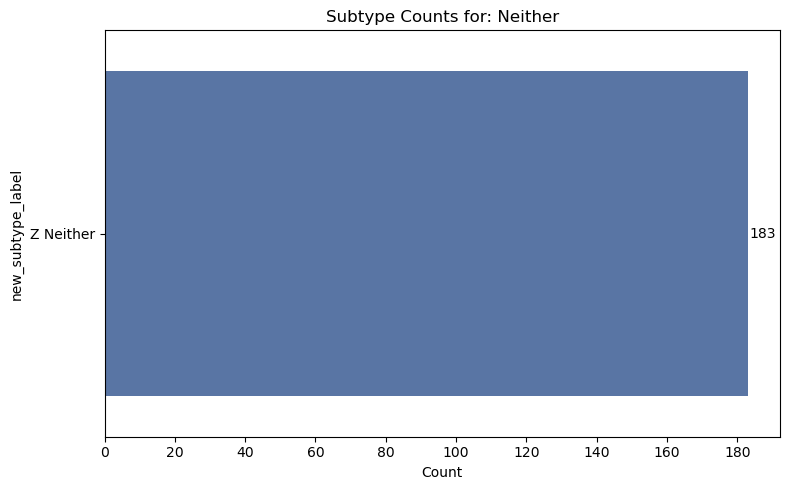

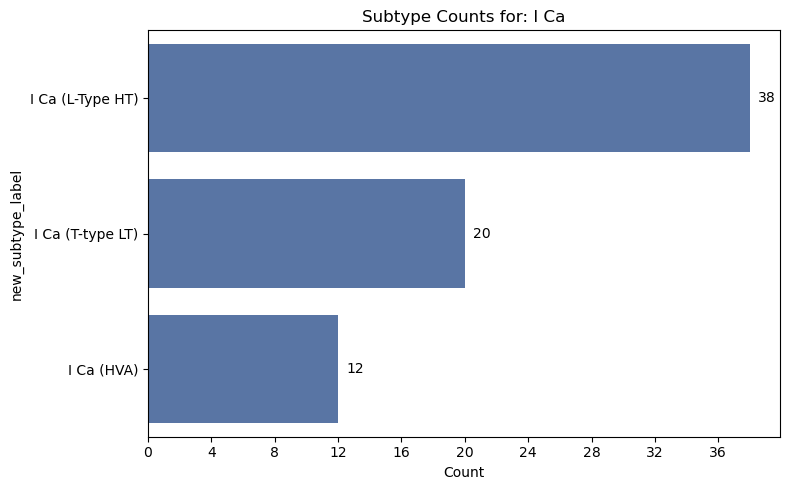

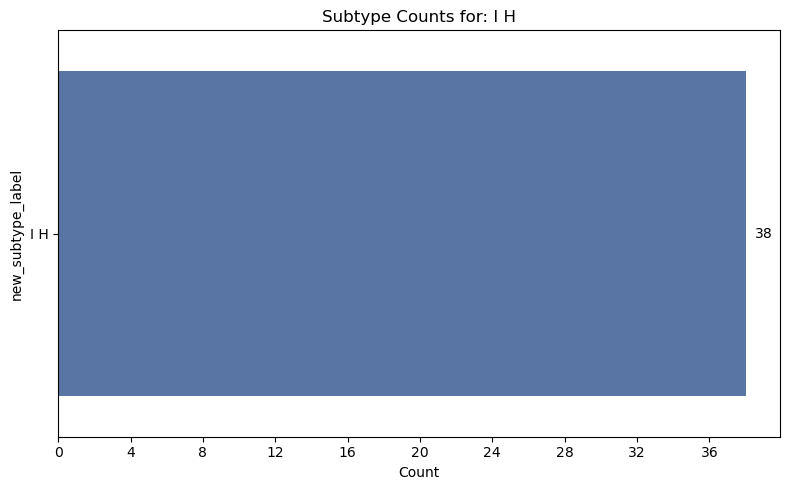

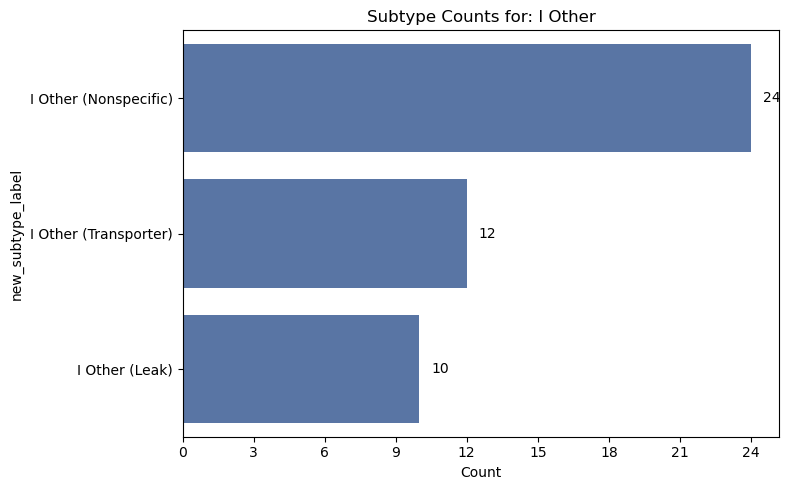

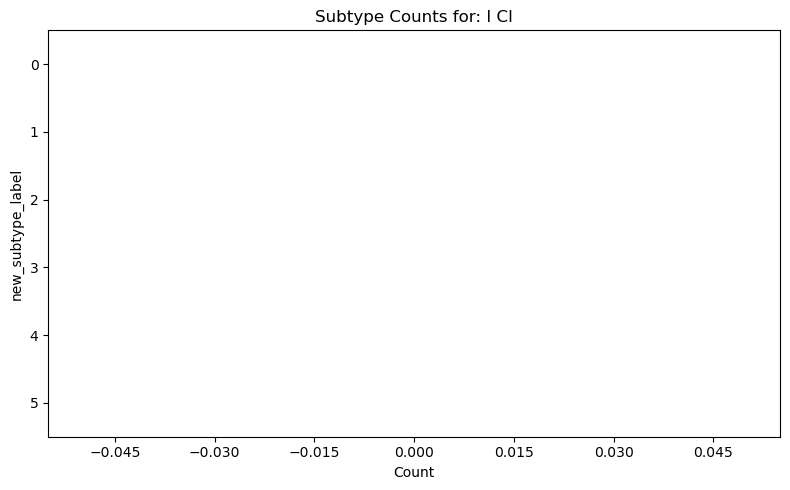

In [12]:
# Loop through each unique type and plot
for t in ant_df_long["type"].dropna().unique():
    plot_countplot(
        df=ant_df_long,
        col='new_subtype_label',
        subset_query=f"type == '{t}'",
        title=f"Subtype Counts for: {t}",
        show_counts=True
    )


In [13]:
#todo: should we remove those < 10?
rare_types = count_df2.query('count<10').sort_values('overall_pct', ascending=False)

In [14]:
labels = [label for label in label_df["new_subtype_label"].unique() if not str(label).startswith("Exclude")]

# Extract label "prefixes" for grouping
def get_prefix(label):
    for separator in [" (", " - "]:
        if separator in label:
            return label.split(separator)[0].strip()
    return label

prefixes = {label: get_prefix(label) for label in labels}

# Initialize similarity matrix
similarity_matrix = pd.DataFrame(0.0, index=labels, columns=labels)

# Fill in similarity scores
for i in labels:
    for j in labels:
        if i == j:
            similarity_matrix.loc[i, j] = 1.0
        elif prefixes[i] == prefixes[j]:
            similarity_matrix.loc[i, j] = 0.5
        elif prefixes[i].split()[0] == prefixes[j].split()[0]:  # e.g., I vs R vs Neither
            similarity_matrix.loc[i, j] = 0.3
        else:
            similarity_matrix.loc[i, j] = 0.0


In [15]:
label_df

,original_type_label,original_subtype_label,robert_subtype_label,new_subtype_label,level1,level2,level3
0,Exclude,Exclude - Not on Model DB,,Exclude,,,
1,Exclude,Exclude - Old Architecture,,Exclude,,,
2,Exclude,Exclude - Accumulation Mechanism,,Exclude,,,
3,I Ca,I Ca (R-Type),I R,I Ca (HVA),I,Ca,HVA
4,I Ca,I Ca (P/Q-Type),"I Ca,p || I p,q",I Ca (HVA),I,Ca,HVA
5,I Ca,I Ca (Q-Type),,I Ca (HVA),I,Ca,HVA
6,I Ca,I Ca (L-Type HT),I L high threshold,I Ca (L-Type HT),I,Ca,HT
8,I Ca,I Ca (T-type LT),I T low threshold,I Ca (T-type LT),I,Ca,T-type LT
11,I H,I H (Hyperpolarization-Activated),I h,I H,I,H,H
12,I K,I K (A-Type Transient),I A,I K (A-type),I,K,A-type


In [16]:
similarity_matrix

,I Ca (HVA),I Ca (L-Type HT),I Ca (T-type LT),I H,I K (A-type),I K (Ca-activated),I K (Delayed Rectifier),I K (M-type),I K (Rare),I Na (General),I Na (Persistent),I Na (Transient),I Other (Leak),I Other (Nonspecific),I Other (Transporter),R GABA,R Glutamate (AMPA),R Glutamate (NMDA),Z Neither
I Ca (HVA),1.0,0.5,0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.0,0.0,0.0,0.0
I Ca (L-Type HT),0.5,1.0,0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.0,0.0,0.0,0.0
I Ca (T-type LT),0.5,0.5,1.0,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.0,0.0,0.0,0.0
I H,0.3,0.3,0.3,1.0,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.0,0.0,0.0,0.0
I K (A-type),0.3,0.3,0.3,0.3,1.0,0.5,0.5,0.5,0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.0,0.0,0.0,0.0
I K (Ca-activated),0.3,0.3,0.3,0.3,0.5,1.0,0.5,0.5,0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.0,0.0,0.0,0.0
I K (Delayed Rectifier),0.3,0.3,0.3,0.3,0.5,0.5,1.0,0.5,0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.0,0.0,0.0,0.0
I K (M-type),0.3,0.3,0.3,0.3,0.5,0.5,0.5,1.0,0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.0,0.0,0.0,0.0
I K (Rare),0.3,0.3,0.3,0.3,0.5,0.5,0.5,0.5,1.0,0.3,0.3,0.3,0.3,0.3,0.3,0.0,0.0,0.0,0.0
I Na (General),0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1.0,0.5,0.5,0.3,0.3,0.3,0.0,0.0,0.0,0.0


# Feature Engineering

In [20]:
#ant_df_long[ant_df_long["new_subtype_label"].isna()].sort_values('row_id')

In [21]:
ant_df_long[ant_df_long["row_id"].duplicated()].sort_values('row_id')

,row_id,file_hash,type,subtype_confidence,notes_free_text,original_subtype_label,original_type_label,new_subtype_label,level1,level2,level3


In [22]:
json_df = pd.read_json("../data/mod_files.json")

In [23]:
json_df2 = (
    json_df
    .merge(ant_df_long, on=["row_id", "file_hash"], how="inner")
    .assign(
        mod_name = lambda df: df["url"].apply(get_fname),
        suffix = lambda df: df["content"].apply(get_suffix),
        read_ion = lambda df: df["content"].apply(get_read_ion),
        read_ion2 = lambda df: df["read_ion"].apply(lambda ion_list: list(set(map_ion(ion) for ion in ion_list)) if isinstance(ion_list, list) else []),
        write_ion = lambda df: df["content"].apply(get_write_ion),
        write_ion2 = lambda df: df["write_ion"].apply(lambda ion_list: list(set(map_ion(ion) for ion in ion_list)) if isinstance(ion_list, list) else []),
        parameter = lambda df: df["content"].apply(get_parameter),
        state = lambda df: df["content"].apply(get_state),
        net_receive = lambda df: df["content"].apply(get_net_receive),
        point_process = lambda df: df["content"].apply(get_point_process),
        nonspecific_current = lambda df: df["content"].apply(get_nonspecific_current),

        # Discrete features
        states_count = lambda df: df["state"].apply(lambda x: len(x) if isinstance(x, list) else 0),

        # Binary features
        clamp_yn = lambda df: df.apply(lambda row: has_electrode_or_clamp(row["mod_name"], row["content"]), axis=1),
        suffix_yn = lambda df: df["suffix"].apply(lambda x: 1 if isinstance(x, list) and len(x) > 0 
                                                  else (0 if pd.isna(x) or x == "none" else 1)),
        point_process_yn = lambda df: df["point_process"].apply(lambda x: 1 if pd.notna(x) else 0),
        net_receive_yn = lambda df: df["net_receive"].apply(lambda x: 1 if isinstance(x, list) and len(x) > 0 else (1 if pd.notna(x) else 0)),
        i_nonspecific_yn = lambda df: df["nonspecific_current"].apply(lambda x: 1 if isinstance(x, list) and len(x) > 0 else (1 if pd.notna(x) else 0)),
        not_ion_channel_yn = lambda df: ((df["suffix_yn"] == 0) & 
                                         df["read_ion"].isna() & 
                                         df["write_ion"].isna() & 
                                         df["nonspecific_current"].isna()).astype(int),
        not_receptor_yn = lambda df: ((df["point_process_yn"] == 0) & 
                                      (df["net_receive_yn"] == 0)).astype(int),
        has_mg_yn = lambda df: df["content"].apply(has_mg),
        has_ih_yn = lambda df: df["content"].apply(has_ih)
    ).reset_index(drop=True)
)      

In [24]:
# Use MultiLabelBinarizer separately for read and write ions
# Reset index before merging to avoid index mismatches
mlb_read = MultiLabelBinarizer()
read_df = pd.DataFrame(mlb_read.fit_transform(json_df2['read_ion2']), 
                                columns=[f'read_{col}_yn' for col in mlb_read.classes_]).reset_index(drop=True)

mlb_write = MultiLabelBinarizer()
write_df = pd.DataFrame(mlb_write.fit_transform(json_df2['write_ion2']), 
                                 columns=[f'write_{col}_yn' for col in mlb_write.classes_]).reset_index(drop=True)

In [30]:
#note: the ones with missing subtype labels are the rare subtypes
#json_df3[json_df3["new_subtype_label"].isna()].shape
json_df3 = json_df2.drop(columns=['read_ion2', 'write_ion2']).join(read_df, rsuffix='_read_dup').join(write_df, rsuffix='_write_dup').dropna(subset=["new_subtype_label"])

In [31]:
print("Total shape", json_df3.shape)
print("Total unique currents/receptors", json_df3["row_id"].nunique())

Total shape (737, 70)
Total unique currents/receptors 737


In [32]:
df_pre = json_df3.set_index('file_hash').filter(regex=r'(_yn|_count|new_subtype_label)$')

In [33]:
df_pre.to_csv("preprocessed_orig.csv")

In [34]:
json_df3[json_df3.new_subtype_label.isna()]

,row_id,file_hash,raw_sha,count,url,download_url,content,error_code,type,subtype_confidence,notes_free_text,original_subtype_label,original_type_label,new_subtype_label,level1,level2,level3,mod_name,suffix,read_ion,write_ion,parameter,state,net_receive,point_process,nonspecific_current,states_count,clamp_yn,suffix_yn,point_process_yn,net_receive_yn,i_nonspecific_yn,not_ion_channel_yn,not_receptor_yn,has_mg_yn,has_ih_yn,read_ca_i_yn,read_ca_o_yn,read_cl_i_yn,read_cl_o_yn,read_e_ca_yn,read_e_k_yn,read_e_na_yn,read_e_other_yn,read_i_cal_yn,read_i_cl_yn,read_i_k_yn,read_i_na_yn,read_i_other_yn,read_k_i_yn,read_k_o_yn,read_na_i_yn,read_na_o_yn,read_other_i_yn,read_other_o_yn,write_ca_i_yn,write_ca_o_yn,write_cl_i_yn,write_cl_o_yn,write_i_cal_yn,write_i_cl_yn,write_i_k_yn,write_i_na_yn,write_i_other_yn,write_k_i_yn,write_k_o_yn,write_na_i_yn,write_na_o_yn,write_other_i_yn,write_unknown_yn


In [64]:
df_pre_new = json_df3.set_index('file_hash').filter(regex=r'(_yn|_count|level1|level2|level3)$')
df_pre_new.to_csv("preprocessed_new.csv")

# XGB model 
- Overall accuracy improved slightly from  0.4524 (in 2025-03-07) to 0.4960 and improved again excluding dirty samples (mixed samples or rare < 10): 0.61
- Link to 2025-03-07 results: https://docs.google.com/presentation/d/1glchNMC5hmDNKWJJXEZWrfv2TXf5l8j0cvdH7K_p4xY/edit?slide=id.g2e3c020b9c3_0_256#slide=id.g2e3c020b9c3_0_256

Cross-validation scores: [0.61016949 0.57627119 0.61864407 0.56779661 0.58119658]
Mean Accuracy (CV): 0.5908
Mean Partial Credit Score: 0.7520


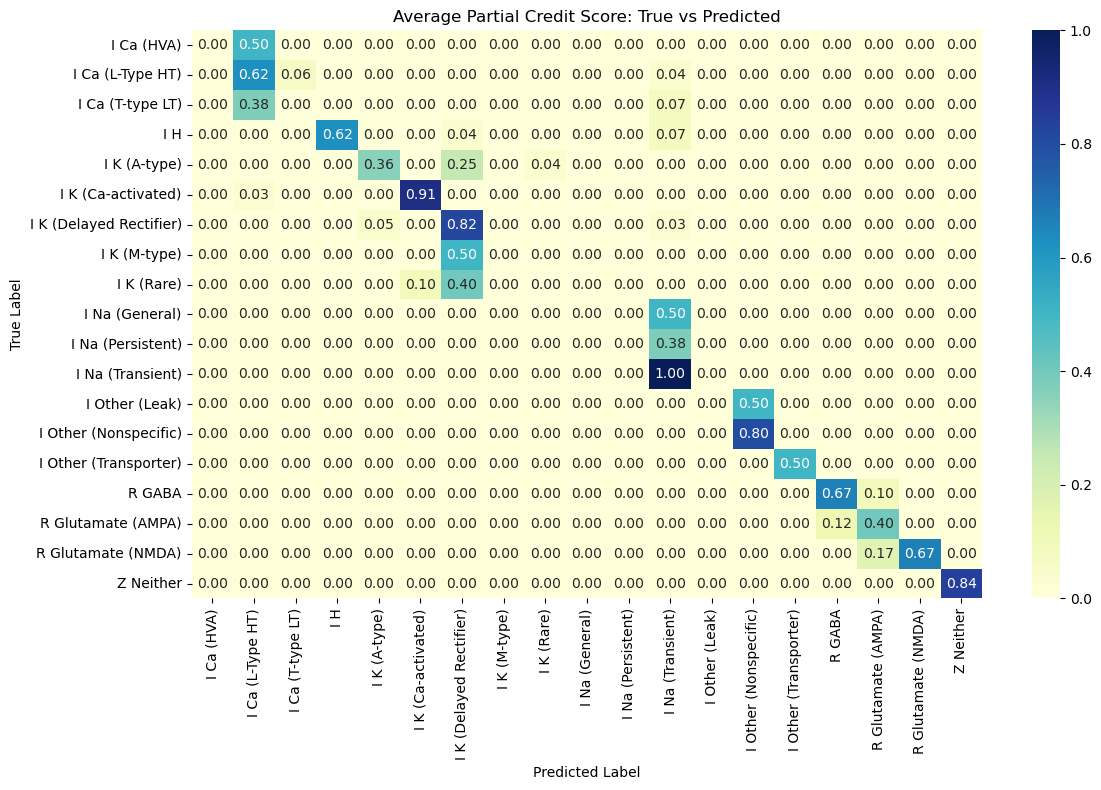

Test Accuracy: 0.6149

Classification Report on Test Set:
                         precision    recall  f1-score   support

             I Ca (HVA)       0.00      0.00      0.00         2
       I Ca (L-Type HT)       0.45      0.62      0.53         8
       I Ca (T-type LT)       0.00      0.00      0.00         4
                    I H       0.83      0.62      0.71         8
           I K (A-type)       0.83      0.36      0.50        14
     I K (Ca-activated)       0.83      0.91      0.87        11
I K (Delayed Rectifier)       0.35      0.82      0.49        11
           I K (M-type)       0.00      0.00      0.00         5
             I K (Rare)       0.00      0.00      0.00         5
         I Na (General)       0.00      0.00      0.00         2
      I Na (Persistent)       0.00      0.00      0.00         4
       I Na (Transient)       0.52      1.00      0.69        11
         I Other (Leak)       0.00      0.00      0.00         2
  I Other (Nonspecific)       0

/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


<Figure size 1000x600 with 0 Axes>

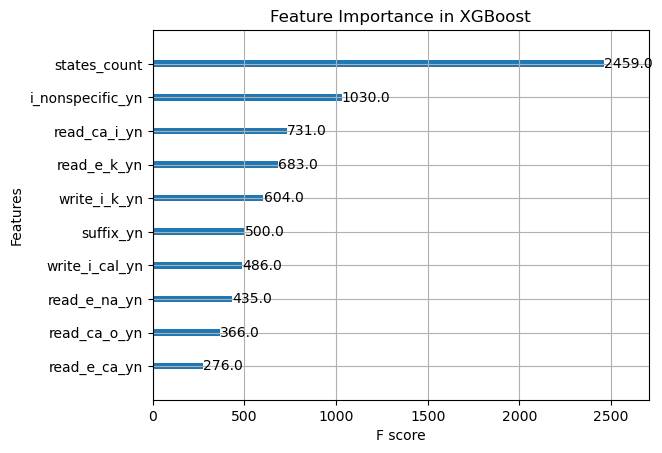

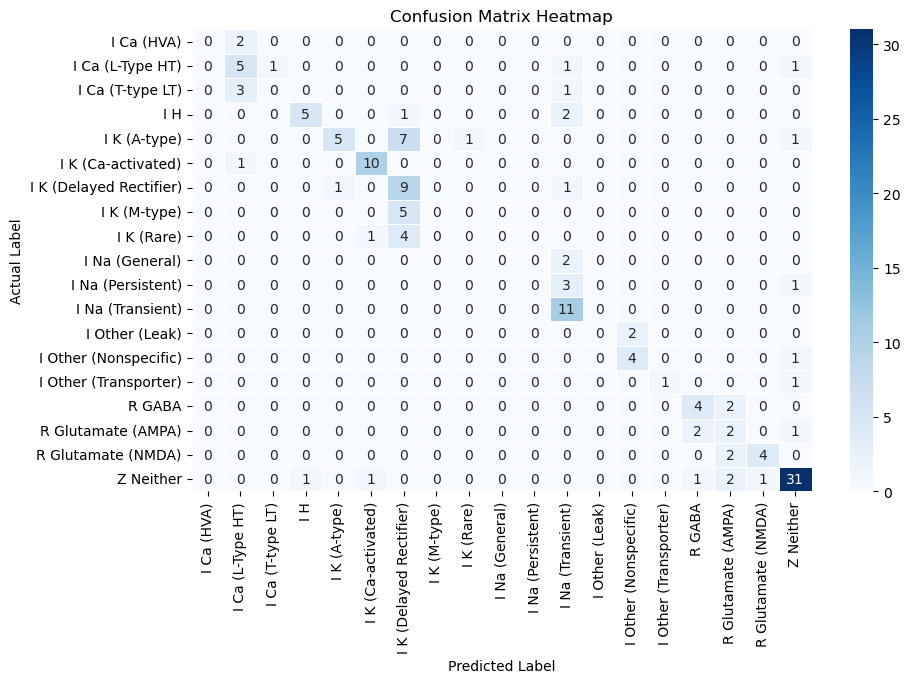

In [67]:
df_pre = pd.read_csv("preprocessed_orig.csv", index_col='file_hash')

# Load and split data
X = df_pre.drop(columns=['new_subtype_label'])  # Features
y = df_pre['new_subtype_label']  # Target

# Stratified 80/20 train-test split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# Merge train/test sets
df_train = X_train.copy()
df_train['new_subtype_label'] = y_train

df_test = X_test.copy()
df_test['new_subtype_label'] = y_test

# Encode categorical labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  
y_test_encoded = label_encoder.transform(y_test)  

# Save the label encoder for later use
with open("label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

# Define XGBoost model
xgb_model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

# Perform 5-Fold Cross-Validation on the Training Set
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X_train, y_train_encoded, cv=kf, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean Accuracy (CV): {cv_scores.mean():.4f}")

# Train on Full Training Set
xgb_model.fit(X_train, y_train_encoded, verbose=True)

# Save the trained XGBoost model
with open("xgb_model.pkl", "wb") as file:
    pickle.dump(xgb_model, file)

# Predict on test set
y_pred_encoded = xgb_model.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_encoded)
y_true = y_test.values

# Compute partial credit
partial_credits = [
    similarity_matrix.loc[true, pred]
    for true, pred in zip(y_true, y_pred)
]

mean_partial_score = sum(partial_credits) / len(partial_credits)
print(f"Mean Partial Credit Score: {mean_partial_score:.4f}")

y_pred_encoded = xgb_model.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_encoded)
y_true = y_test.values

plot_partial_credit_heatmap(y_true, y_pred, similarity_matrix)

from sklearn.metrics import classification_report, accuracy_score

# Predict on test data
y_test_pred_enc = xgb_model.predict(X_test)  # Get encoded predictions

# Convert predictions back to original labels
y_test_pred = label_encoder.inverse_transform(y_test_pred_enc)

# Accuracy on test data
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate classification report with meaningful labels
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

df_train.shape
df_test.shape
# Plot feature importances
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10)  # Show top 10 features
plt.title("Feature Importance in XGBoost")
plt.show()


import pandas as pd
from sklearn.metrics import confusion_matrix

# Ensure predictions are in encoded numeric form
y_test_pred_encoded = label_encoder.transform(y_test_pred)  # Convert back to numeric if necessary

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred_encoded)

# Convert to DataFrame for better visualization
conf_df = pd.DataFrame(conf_matrix, 
                       index=label_encoder.classes_, 
                       columns=label_encoder.classes_)


import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [68]:
import pandas as pd
import numpy as np

def get_metrics_df(conf_input, labels=None):
    """
    Compute per-class metrics from a confusion matrix:
    - True Positives (TP)
    - Count (actual count per class)
    - TP % (precision of correct predictions per class)
    
    Parameters:
        conf_input (DataFrame or ndarray): Confusion matrix
        labels (list, optional): List of class labels if conf_input is ndarray
        
    Returns:
        DataFrame with metrics per class
    """
    # Convert to DataFrame if input is a NumPy array
    if isinstance(conf_input, np.ndarray):
        if labels is None:
            raise ValueError("Must provide 'labels' if confusion matrix is a NumPy array.")
        conf_df = pd.DataFrame(conf_input, index=labels, columns=labels)
    else:
        conf_df = conf_input.copy()
    
    metrics_df = pd.DataFrame(index=conf_df.index)
    metrics_df["True Positives"] = conf_df.values.diagonal()
    metrics_df["Count"] = conf_df.sum(axis=1).values
    metrics_df["TP %"] = 100 * metrics_df["True Positives"] / metrics_df["Count"]
    metrics_df = metrics_df.round(2)
    
    return metrics_df


In [ ]:
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred_encoded)
metrics_df = get_metrics_df(conf_matrix, labels=label_encoder.classes_)
print(metrics_df)


In [ ]:
# Create an explainer
explainer = shap.Explainer(xgb_model, X_test)

# Compute SHAP values
shap_values = explainer(X_test)
#plt.title("I H")
#plt.title("I K A-type")
#plt.title("I KDR")

#shap.plots.beeswarm(shap_values[:,:,5])

In [49]:
!git add .
!git commit -m "added tp, tp%, and count"
!git push

[main efe8a48] added tp, tp%, and count
 1 file changed, 164 insertions(+), 28 deletions(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 64 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 92.15 KiB | 4.85 MiB/s, done.
Total 4 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To github.com:innacohen/mod-extract.git
   a86a0b1..efe8a48  main -> main


In [ ]:
#df_long[df_long["gpt_pred"]!="check"]

In [50]:
df_xgb_pred = pd.DataFrame({"hash": X_test.index, "xgb_pred": y_test_pred, "new_subtype_label":y_test}).set_index("hash")  # XGB predictions
df_xgb_pred = df_xgb_pred.reset_index()

In [51]:
df_both = df_xgb_pred.merge(gpt_df3, how="inner")

In [52]:
df_both = df_both.rename(columns={"currents": "gpt_pred"})  # adjust as needed


GPT Model Accuracy: 0.7736
Classification Report for GPT Model:
                         precision    recall  f1-score   support

             I Ca (HVA)       1.00      1.00      1.00         2
       I Ca (L-Type HT)       1.00      0.88      0.93         8
       I Ca (T-type LT)       1.00      1.00      1.00         4
                    I H       1.00      0.88      0.93         8
           I K (A-type)       1.00      1.00      1.00        24
     I K (Ca-activated)       0.67      1.00      0.80         4
I K (Delayed Rectifier)       0.00      0.00      0.00         8
           I K (M-type)       1.00      1.00      1.00         4
             I K (Rare)       0.25      1.00      0.40         3
         I Na (General)       0.00      0.00      0.00         1
      I Na (Persistent)       1.00      1.00      1.00         3
       I Na (Transient)       0.88      1.00      0.93         7
  I Other (Nonspecific)       0.67      1.00      0.80         2
  I Other (Transporter)  

/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


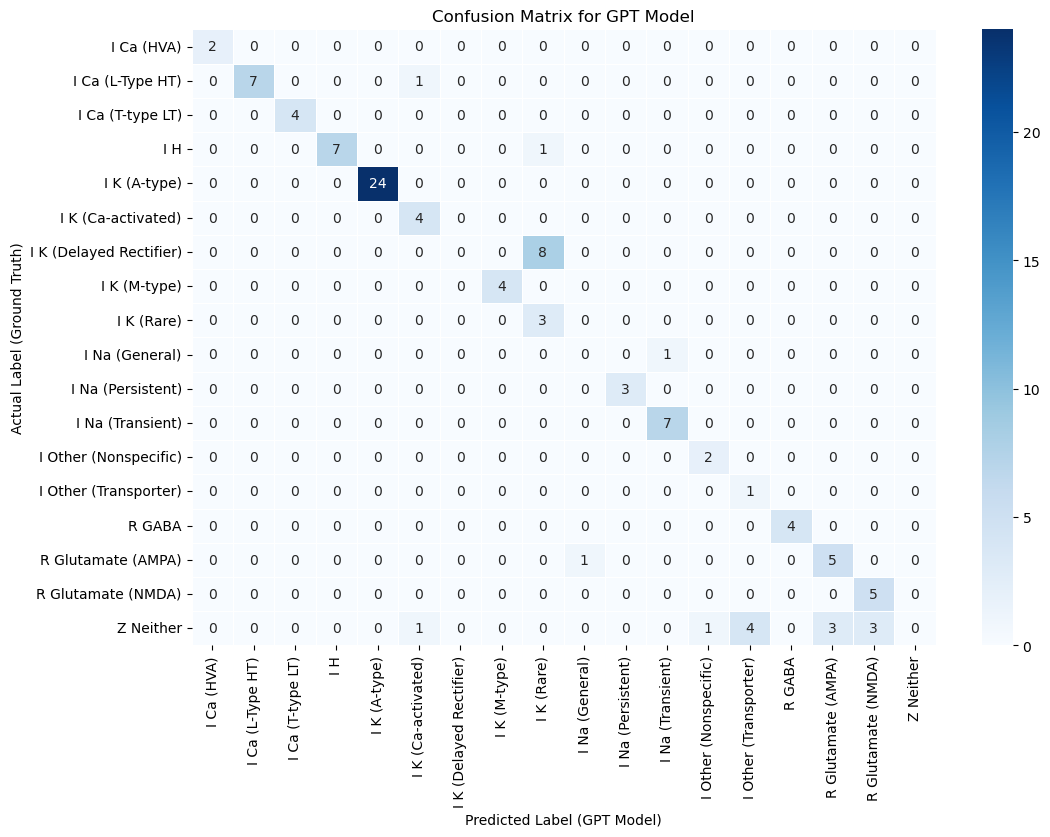

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Extract ground truth labels and GPT predictions
y_true = df_both["new_subtype_label"]  # True labels
y_pred = df_both["gpt_pred"]  # GPT model predictions

# Compute accuracy
gpt_accuracy = accuracy_score(y_true, y_pred)
print(f"GPT Model Accuracy: {gpt_accuracy:.4f}")

# Generate classification report
print("Classification Report for GPT Model:")
print(classification_report(y_true, y_pred))

# Ensure labels include all from both y_true and y_pred
labels = np.unique(np.concatenate([y_true, y_pred]))

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)

# Convert confusion matrix to DataFrame for visualization
conf_df = pd.DataFrame(conf_matrix, index=labels, columns=labels)

# Compute True Positives and TP %
metrics_df = pd.DataFrame(index=labels)
metrics_df["True Positives"] = conf_df.values.diagonal()
metrics_df["Count"] = conf_df.sum(axis=1).values
metrics_df["TP %"] = 100 * metrics_df["True Positives"] / metrics_df["Count"]
metrics_df = metrics_df.round(2)

# 🔹 Plot Confusion Matrix Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.xlabel("Predicted Label (GPT Model)")
plt.ylabel("Actual Label (Ground Truth)")
plt.title("Confusion Matrix for GPT Model")
plt.show()


In [61]:
metrics_df

,True Positives,Count,TP %
I Ca (HVA),2,2,100.00
I Ca (L-Type HT),7,8,87.50
I Ca (T-type LT),4,4,100.00
I H,7,8,87.50
I K (A-type),24,24,100.00
I K (Ca-activated),4,4,100.00
I K (Delayed Rectifier),0,8,0.00
I K (M-type),4,4,100.00
I K (Rare),3,3,100.00
I Na (General),0,1,0.00
